In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors",
           "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width",
           "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size",
           "fuel-system", "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
           "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=columns, na_values="?")

In [3]:
# Quick cleanup
df = df.dropna(subset=['price', 'horsepower', 'peak-rpm'])

print(f"Dataset Loaded. Shape: {df.shape}")

Dataset Loaded. Shape: (199, 26)


In [4]:
print(df.columns)
#print seleted column values
print(df[['symboling','make', 'num-of-doors', 'engine-size']].head())

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')
   symboling         make num-of-doors  engine-size
0          3  alfa-romero          two          130
1          3  alfa-romero          two          130
2          1  alfa-romero          two          152
3          2         audi         four          109
4          2         audi         four          136


# **Part 1: Data Types & Measurement Levels**

**Classifying each of those 4 columns:**

```
      symboling -> Qualitative (Ordinal)
      make -> Qualitative (Nominal)
      num-of-doors -> Qualitative (Nominal)
      engine-size -> Quantitative (Ratio)

```

```
Q: Why is symboling Ordinal/Interval and not Ratio?
A:The values in 'symboling' column defines risk rating from -3 to +3, higher the number higher the risk. So these numbers act as labels of risks not any quantity.
Ratio data requires true zero but here 0 means average risk.
```

# **Part 2: Central Tendency & Dispersion (The Price Analysis)**

Mean price: 13243.43216080402, Median price: 10345.0, Mode price: 5572.0
The distribution is right-skewed.


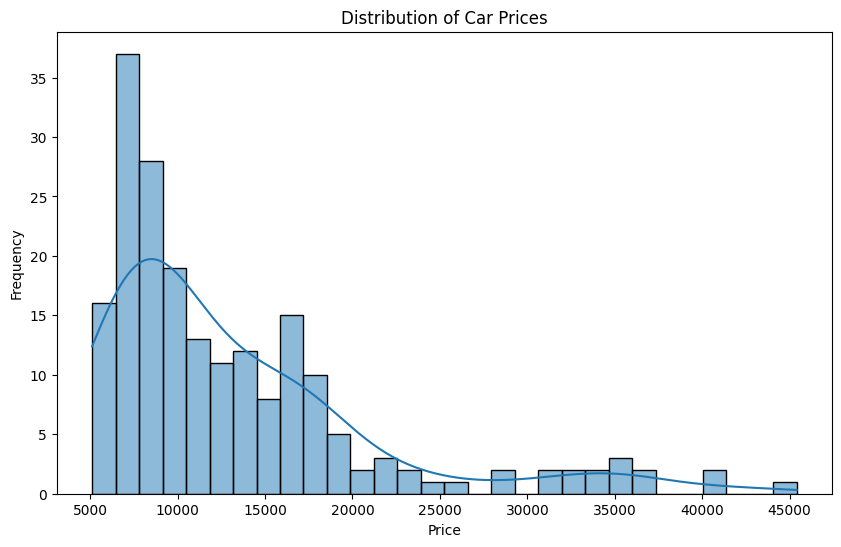

Coefficient of Variation for Price: 60.25%
Coefficient of Variation for Horsepower: 36.32%


In [9]:
#computing mean, median and mode for 'price' column
mean_price = df['price'].astype(float).mean()
median_price = df['price'].astype(float).median()
mode_price = df['price'].astype(float).mode()[0]
print(f"Mean price: {mean_price}, Median price: {median_price}, Mode price: {mode_price}")

if mean_price > median_price:
    print("The distribution is right-skewed.")
elif mean_price < median_price:
    print("The distribution is left-skewed.")
else:
    print("The distribution is symmetric.")

# Visualizing the distribution of 'price'
plt.figure(figsize=(10, 6))
sns.histplot(df['price'].astype(float), bins=30, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# calculating the coiefficient of variation (CV) fir 'price' and 'horsepower'
def coefficient_of_variation(series):
    return series.std() / series.mean() * 100
cv_price = coefficient_of_variation(df['price'].astype(float))
cv_horsepower = coefficient_of_variation(df['horsepower'].astype(float))
print(f"Coefficient of Variation for Price: {cv_price:.2f}%")
print(f"Coefficient of Variation for Horsepower: {cv_horsepower:.2f}%")




```

Q:Is the Mean > Median?
A: Yes
Q:What does this tell you about the distribution of prices?
A: There are expensive cars pulling it up (i.e. 40000,45000)
Q: Which metric is more volatile (variable) across the market: Price or Horsepower?
A: Price is more volatile than Horsepower because its Coefficient of Variation (60.25%) is significantly higher than that of Horsepower (36.32%)
```